In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
customers = pd.read_csv("../cleaned_datasets/cleaned_customers.csv")

orders = pd.read_csv("../cleaned_datasets/cleaned_orders.csv")

order_items = pd.read_csv("../cleaned_datasets/cleaned_order_items.csv")

payments = pd.read_csv("../cleaned_datasets/cleaned_payments.csv")

reviews = pd.read_csv("../cleaned_datasets/cleaned_reviews.csv")

products = pd.read_csv("../cleaned_datasets/cleaned_products.csv")

sellers = pd.read_csv("../cleaned_datasets/cleaned_sellers.csv")

geolocation = pd.read_csv("../cleaned_datasets/cleaned_geolocation.csv")

category_translation = pd.read_csv("../cleaned_datasets/cleaned_category_translation.csv")

In [16]:
payments = payments.drop(columns="Unnamed: 0")
reviews = reviews.drop(columns="Unnamed: 0")
products = products.drop(columns="Unnamed: 0")
sellers = sellers.drop(columns="Unnamed: 0")
geolocation = geolocation.drop(columns="Unnamed: 0")
category_translation = category_translation.drop(columns="Unnamed: 0")

In [17]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

In [18]:
for name, df in datasets.items():
    print(name, ":", df.shape)

Customers : (99441, 5)
Orders : (99441, 8)
Order Items : (112650, 7)
Payments : (103886, 5)
Reviews : (99224, 7)
Products : (32950, 9)
Sellers : (3095, 4)
Geolocation : (738307, 5)
Category Translation : (71, 2)


In [19]:
for name, df in datasets.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print(df.info())


Customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       9

In [20]:
for name, df in datasets.items():
    print("\n", name)
    display(df.describe())


 Customers


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000



 Orders


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522



 Order Items


...

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000



 Geolocation


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,738307.000000,738307.000000,738307.000000
mean,38315.493070,-21.000104,-46.461978
std,30632.514235,5.883433,4.382980
min,1001.000000,-34.622400,-72.930746
25%,12600.000000,-23.603071,-48.867831
50%,29144.000000,-22.873623,-46.647299
75%,65950.000000,-19.923396,-43.837210
max,99990.000000,4.482242,-32.402779



 Category Translation


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [21]:
customer_state_counts = customers["customer_state"].value_counts()

customer_state_counts

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

# Customer EDA

Customer data is analyzed to understand customer distribution and purchasing behavior.

### Analysis
- Customers by state
- Customers by city
- Orders per unique customer

In [22]:
customer_state_counts = customers["customer_state"].value_counts()

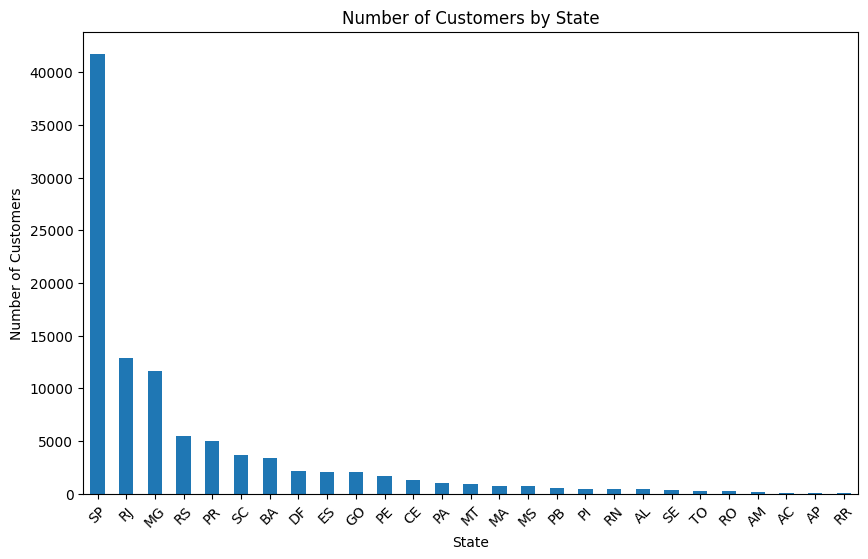

In [23]:
plt.figure(figsize=(10, 6))

customer_state_counts.plot(kind="bar")

plt.title("Number of Customers by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

### Observation

The customer distribution varies significantly across states. São Paulo (SP) has the highest number of customers, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). The states with fewer customers include Roraima (RR), Amapá (AP), and Acre (AC).

In [24]:
customer_city_counts = customers["customer_city"].value_counts().head(10)

customer_city_counts

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

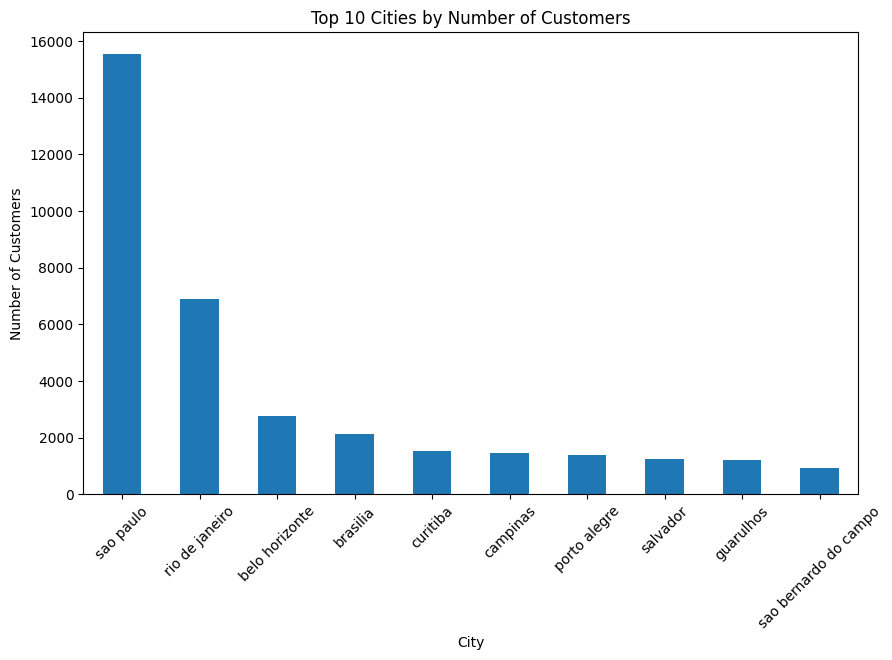

In [25]:
plt.figure(figsize=(10, 6))

customer_city_counts.plot(kind="bar")

plt.title("Top 10 Cities by Number of Customers")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

### Observation

São Paulo has the highest number of customers, followed by Rio de Janeiro and Belo Horizonte.

In [26]:
customer_order_counts = customers["customer_unique_id"].value_counts()

customer_order_counts.head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
12f5d6e1cbf93dafd9dcc19095df0b3d     6
dc813062e0fc23409cd255f7f53c7074     6
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
de34b16117594161a6a89c50b289d35a     6
63cfc61cee11cbe306bff5857d00bfe4     6
Name: count, dtype: int64

In [27]:
customer_order_counts.value_counts().head(10)

count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
17        1
9         1
Name: count, dtype: int64

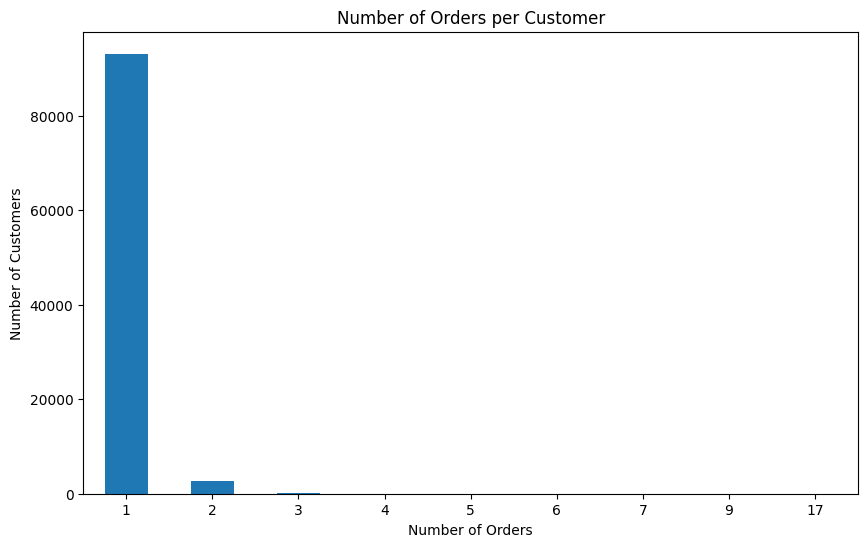

In [28]:
plt.figure(figsize=(10, 6))

customer_order_counts.value_counts().sort_index().plot(kind="bar")

plt.title("Number of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

### Observation

Most customers placed only one order, while a smaller number of customers made repeat purchases.

# Orders EDA

Order data is analyzed to understand order status and order trends.

### Analysis
- Order status distribution
- Orders over time
- Delivery performance

In [29]:
order_status_counts = orders["order_status"].value_counts()

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

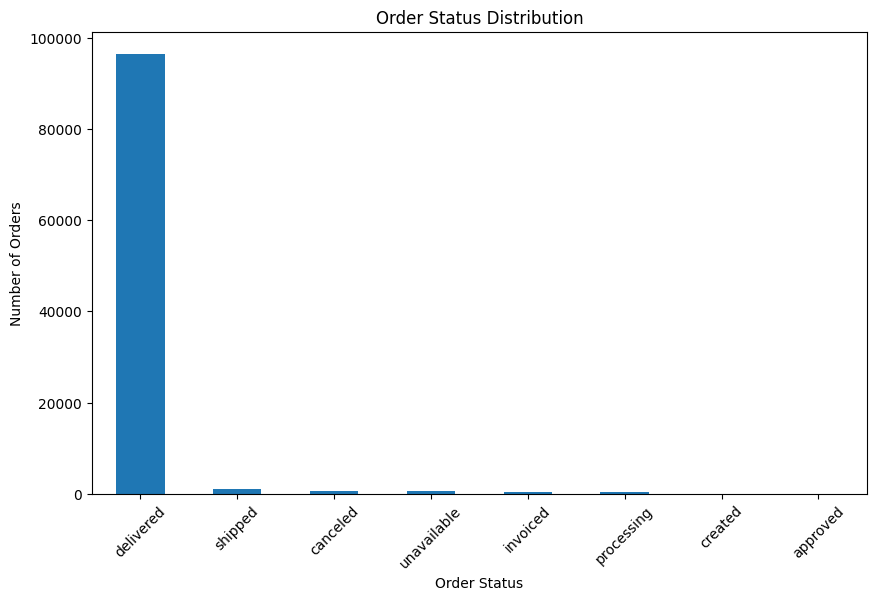

In [30]:
plt.figure(figsize=(10, 6))

order_status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Observation

Delivered orders are much higher than the other order statuses, while created and approved orders are very few.

In [31]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"])

In [32]:
monthly_orders = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)
monthly_orders

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

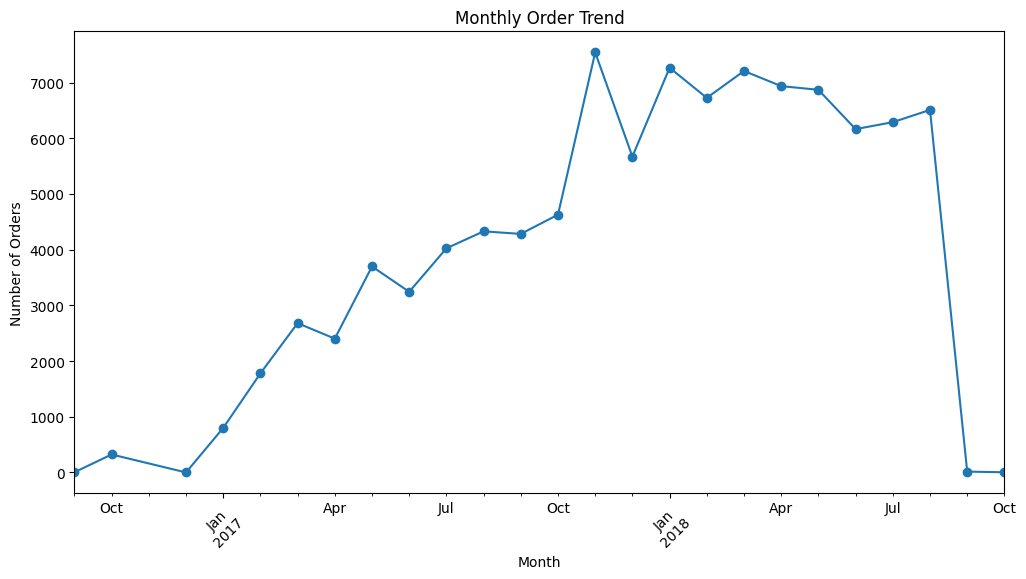

In [33]:
plt.figure(figsize=(12, 6))

monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

### Observation

Orders increased over time, with the highest number of orders recorded in November 2017.

In [34]:
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [35]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [36]:
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.days

delivered_orders[["order_id", "delivery_days"]].head()

,order_id,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0


In [37]:
delivered_orders["delivery_days"].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

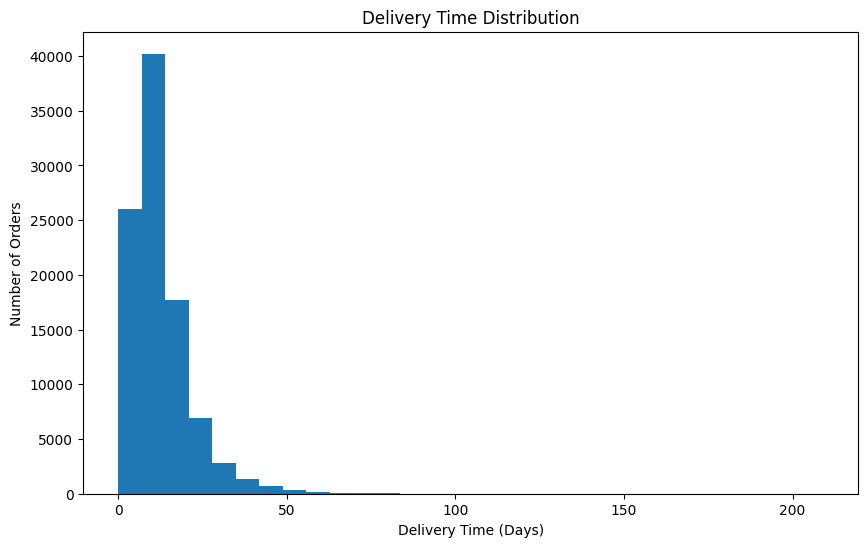

In [38]:
plt.figure(figsize=(10, 6))

delivered_orders["delivery_days"].plot(kind="hist", bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.show()

### Observation

Most orders were delivered within a short period, with delivery times concentrated around 5–15 days. A small number of orders took much longer to be delivered.

# Order Items EDA

Order item data is analyzed to understand product sales and pricing.

### Analysis
- Product prices
- Freight values
- Items per order

In [39]:
order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

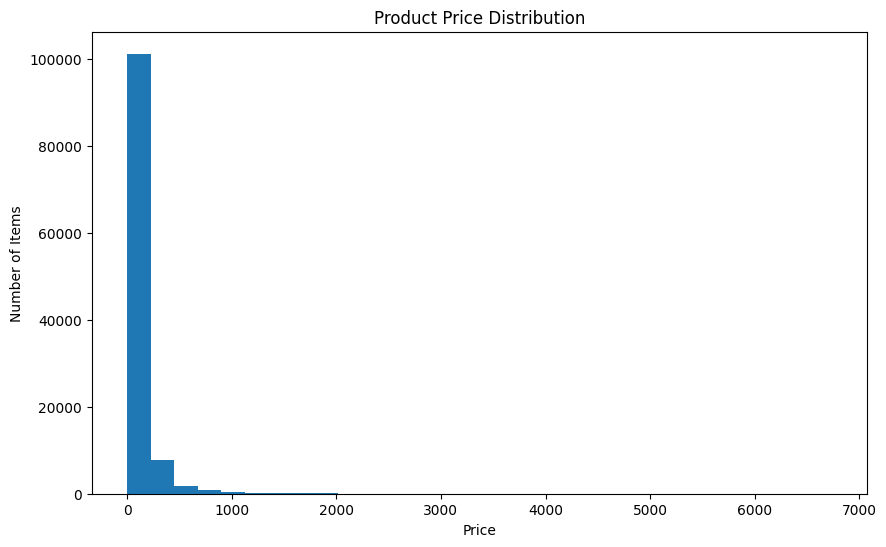

In [40]:
plt.figure(figsize=(10, 6))

order_items["price"].plot(kind="hist", bins=30)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Items")
plt.show()

### Observation

Most product prices are concentrated at the lower end, while a small number of products have much higher prices.

In [41]:
order_items["freight_value"].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

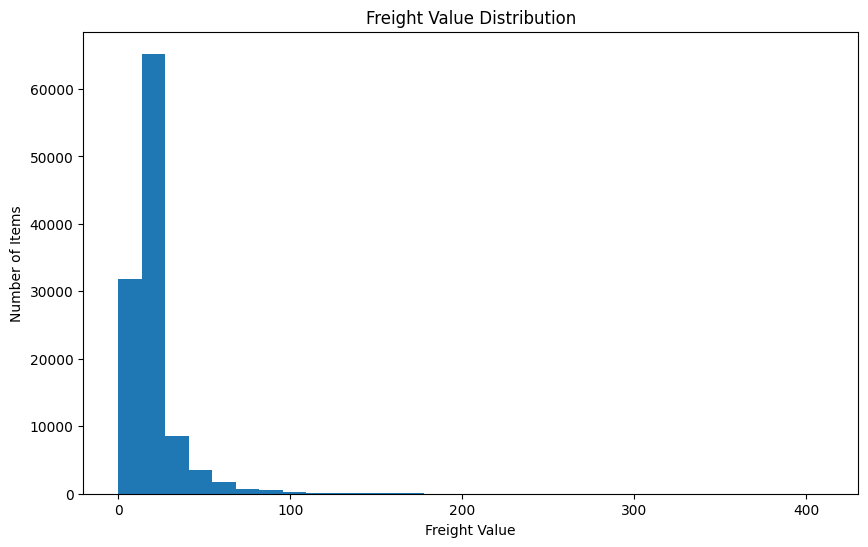

In [42]:
plt.figure(figsize=(10, 6))

order_items["freight_value"].plot(kind="hist", bins=30)

plt.title("Freight Value Distribution")
plt.xlabel("Freight Value")
plt.ylabel("Number of Items")
plt.show()

### Observation

Most freight values are concentrated at the lower end, while a small number of items have much higher freight costs.

In [43]:
items_per_order = order_items["order_id"].value_counts()

items_per_order.head(10)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
9bdc4d4c71aa1de4606060929dee888c    14
73c8ab38f07dc94389065f7eba4f297a    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
af822dacd6f5cff7376413c03a388bb7    12
3a213fcdfe7d98be74ea0dc05a8b31ae    12
Name: count, dtype: int64

In [44]:
items_per_order.describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: count, dtype: float64

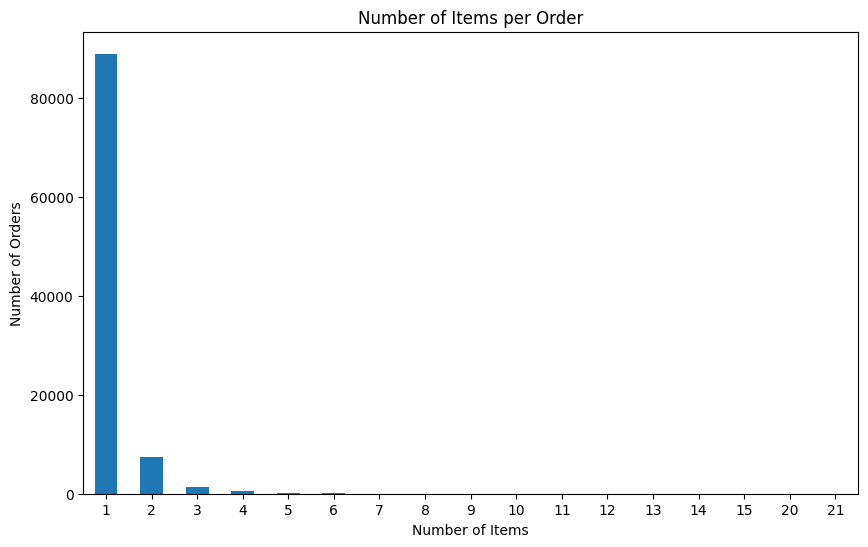

In [45]:
plt.figure(figsize=(10, 6))

items_per_order.value_counts().sort_index().plot(kind="bar")

plt.title("Number of Items per Order")
plt.xlabel("Number of Items")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

### Observation

Most orders contain only one item, while orders with multiple items are much less common.

# Payments EDA

Payment data is analyzed to understand payment methods and payment behavior.

### Analysis
- Payment types
- Payment installments
- Payment values

In [46]:
payment_type_counts = payments["payment_type"].value_counts()

payment_type_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

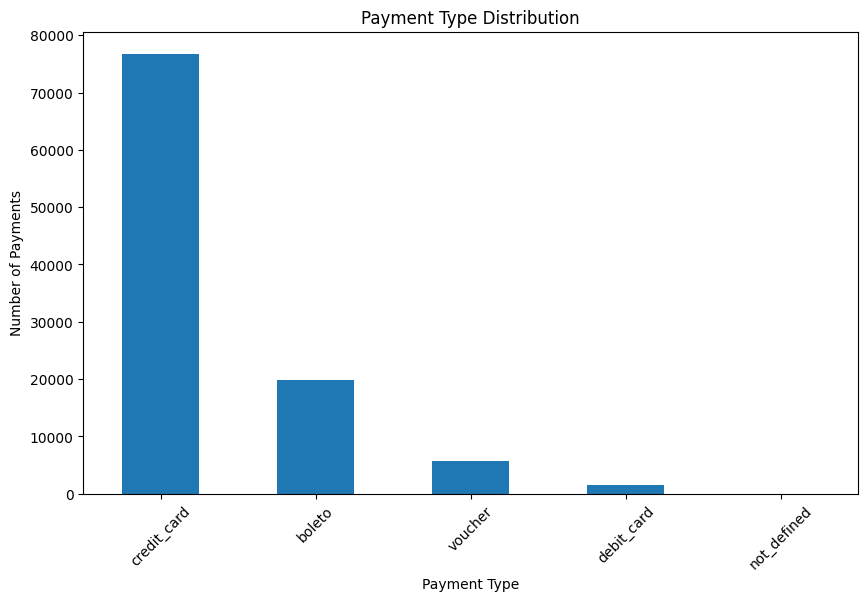

In [47]:
plt.figure(figsize=(10, 6))

payment_type_counts.plot(kind="bar")

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")
plt.xticks(rotation=45)
plt.show()

### Observation

Credit card is the most commonly used payment method, followed by boleto. Debit card and not defined payments are much less common.

In [48]:
installment_counts = payments["payment_installments"].value_counts().sort_index()

installment_counts

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

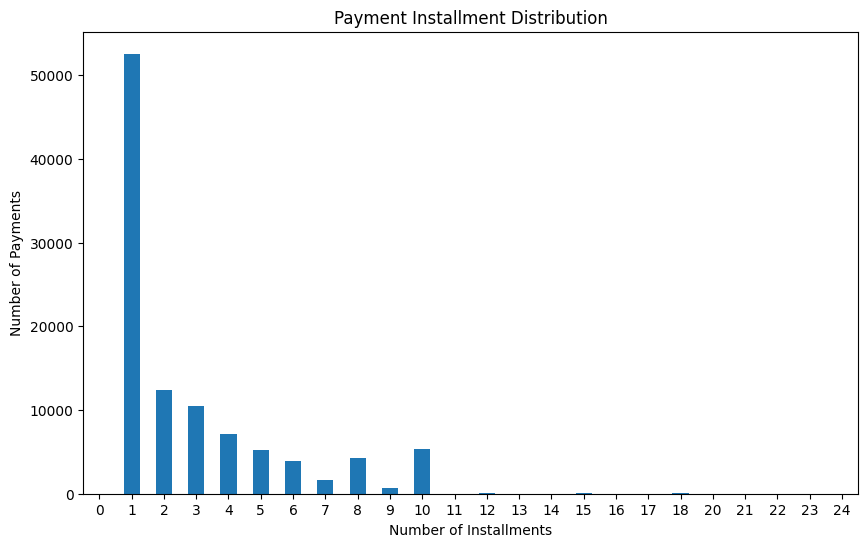

In [49]:
plt.figure(figsize=(10, 6))

installment_counts.plot(kind="bar")

plt.title("Payment Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Payments")
plt.xticks(rotation=0)
plt.show()

### Observation

Most payments were made using a single installment, while fewer payments used multiple installments. A small number of payments used higher installment counts.

In [50]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

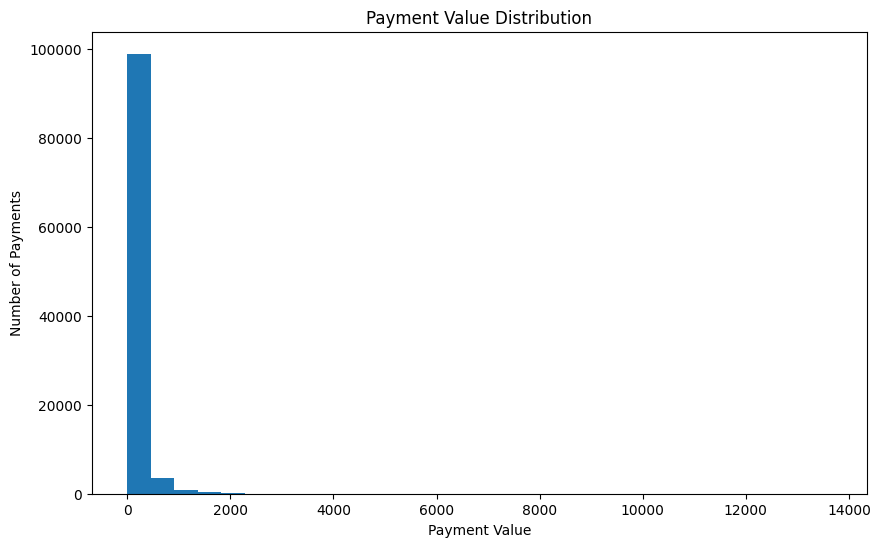

In [51]:
plt.figure(figsize=(10, 6))
payments["payment_value"].plot(kind="hist", bins=30)
plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Number of Payments")
plt.show()

### Observation

Most payment values are concentrated at the lower end, while a small number of payments have much higher values.

# Reviews EDA

Review data is analyzed to understand customer satisfaction.

### Analysis
- Review score distribution
- Review scores by order status
- Review comments

In [52]:
review_score_counts = reviews["review_score"].value_counts().sort_index()
review_score_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

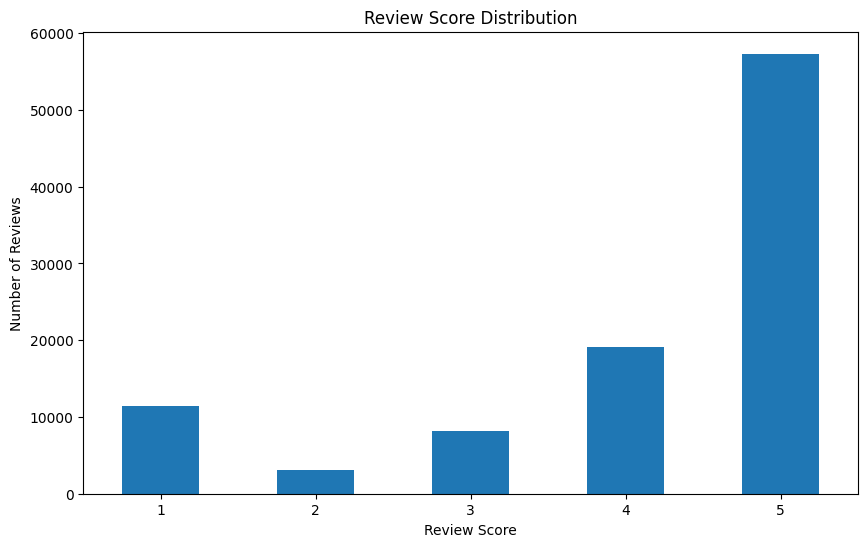

In [53]:
plt.figure(figsize=(10, 6))
review_score_counts.plot(kind="bar")
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

### Observation

5-star reviews are the most common, followed by 4-star reviews, while 2-star reviews are the least common.

In [54]:
review_order_data = reviews.merge(
    orders[["order_id", "order_status"]],
    on="order_id",
    how="left"
)

review_order_data.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_status
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59,delivered
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13,delivered
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24,delivered
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,delivered
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,delivered


In [55]:
review_score_by_status = (
    review_order_data.groupby("order_status")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

review_score_by_status

order_status
delivered      4.155717
approved       2.500000
created        2.333333
shipped        2.008629
canceled       1.811166
invoiced       1.661342
unavailable    1.530988
processing     1.277027
Name: review_score, dtype: float64

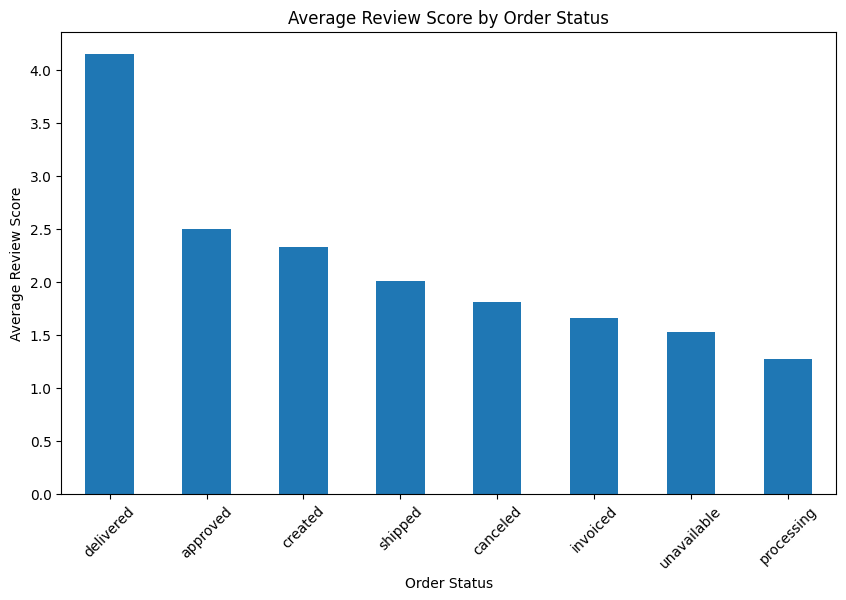

In [56]:
plt.figure(figsize=(10, 6))
review_score_by_status.plot(kind="bar")
plt.title("Average Review Score by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.show()

### Observation

Delivered orders have the highest average review score, while processing orders have the lowest average review score.

In [57]:
comment_counts = reviews["review_comment_message"].notna().value_counts()
comment_counts

review_comment_message
False    58247
True     40977
Name: count, dtype: int64

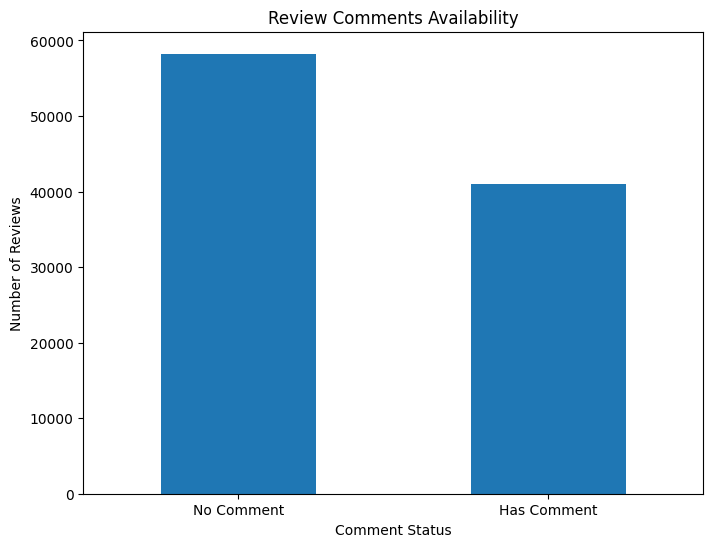

In [58]:
comment_counts.index = ["No Comment", "Has Comment"]

plt.figure(figsize=(8, 6))
comment_counts.plot(kind="bar")
plt.title("Review Comments Availability")
plt.xlabel("Comment Status")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

### Observation

Most reviews do not contain a comment, while a smaller number of reviews include comments.

# Products EDA

Product data is analyzed to understand product categories and characteristics.

### Analysis
- Product categories
- Product dimensions
- Product weight

In [59]:
product_category_counts = products["product_category_name"].value_counts().head(10)
product_category_counts

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

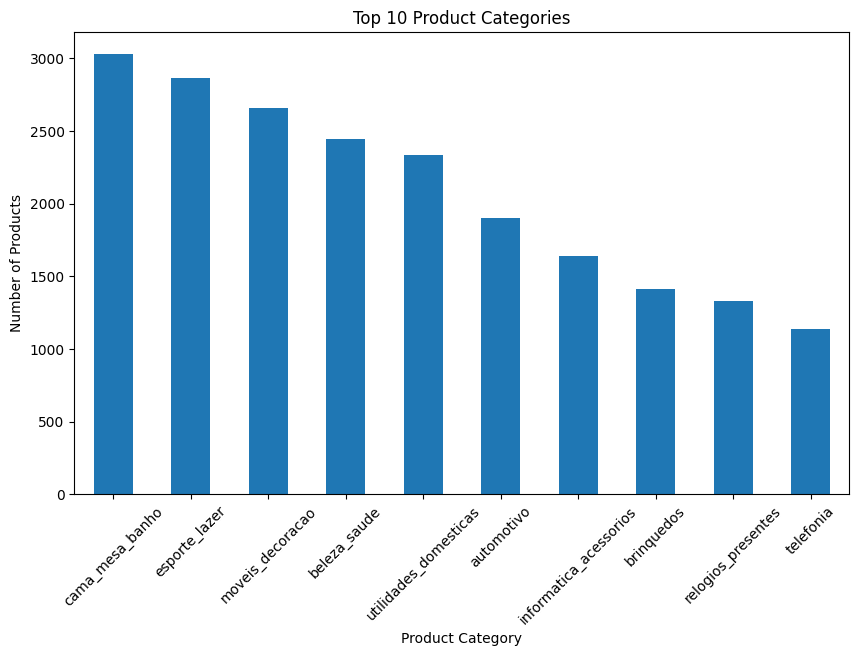

In [60]:
plt.figure(figsize=(10, 6))
product_category_counts.plot(kind="bar")
plt.title("Top 10 Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

### Observation

Cama, mesa, banho has the highest number of products among the top 10 categories, followed by esporte, lazer and moveis, decoracao.

In [61]:
products[["product_length_cm", "product_height_cm", "product_width_cm"]].describe()

,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000
mean,30.815078,16.937661,23.196728
std,16.914458,13.637554,12.079047
min,7.000000,2.000000,6.000000
25%,18.000000,8.000000,15.000000
50%,25.000000,13.000000,20.000000
75%,38.000000,21.000000,30.000000
max,105.000000,105.000000,118.000000


In [62]:
dimension_means = products[
    ["product_length_cm", "product_height_cm", "product_width_cm"]
].mean()

dimension_means

product_length_cm    30.815078
product_height_cm    16.937661
product_width_cm     23.196728
dtype: float64

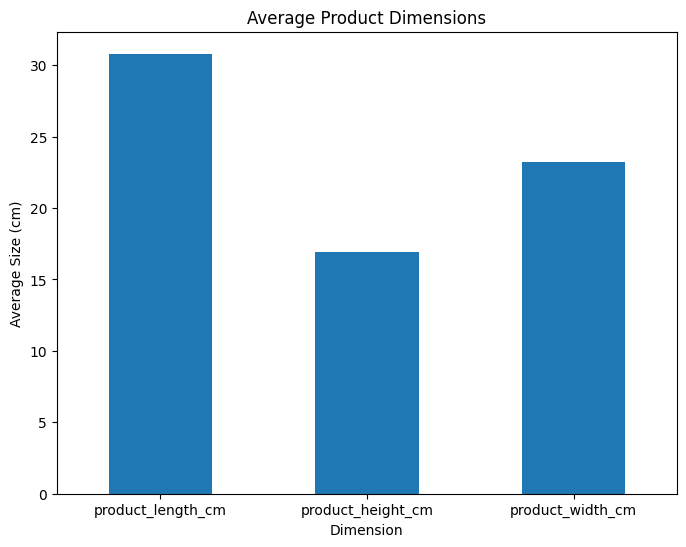

In [63]:
plt.figure(figsize=(8, 6))
dimension_means.plot(kind="bar")
plt.title("Average Product Dimensions")
plt.xlabel("Dimension")
plt.ylabel("Average Size (cm)")
plt.xticks(rotation=0)
plt.show()

### Observation

The average product length is the highest, followed by product width, while product height has the lowest average value.

In [64]:
products["product_weight_g"].describe()

count    32949.000000
mean      2276.472488
std       4282.038731
min          0.000000
25%        300.000000
50%        700.000000
75%       1900.000000
max      40425.000000
Name: product_weight_g, dtype: float64

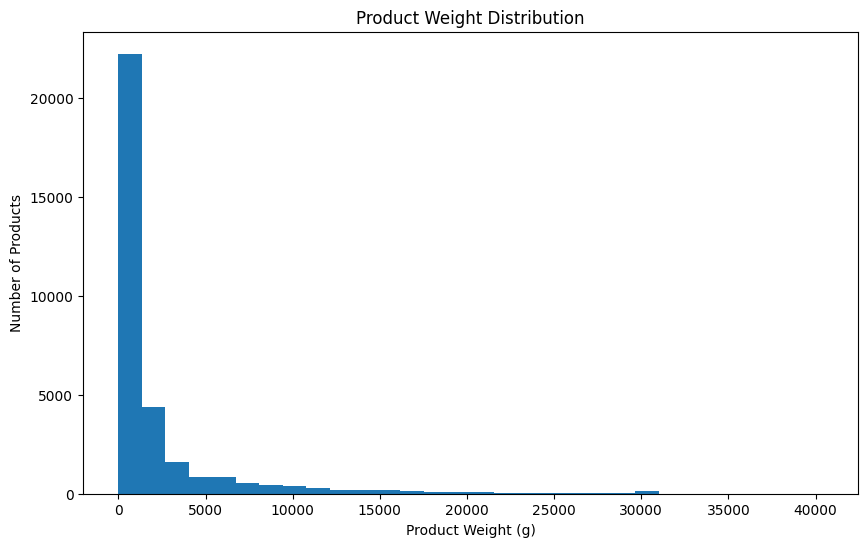

In [65]:
plt.figure(figsize=(10, 6))
products["product_weight_g"].plot(kind="hist", bins=30)
plt.title("Product Weight Distribution")
plt.xlabel("Product Weight (g)")
plt.ylabel("Number of Products")
plt.show()

### Observation

Most products have lower weights, while a smaller number of products have much higher weights. The distribution is strongly right-skewed.

# Sellers EDA

Seller data is analyzed to understand seller distribution and activity.

### Analysis
- Sellers by state
- Sellers by city
- Seller activity

In [66]:
seller_state_counts = sellers["seller_state"].value_counts()
seller_state_counts

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

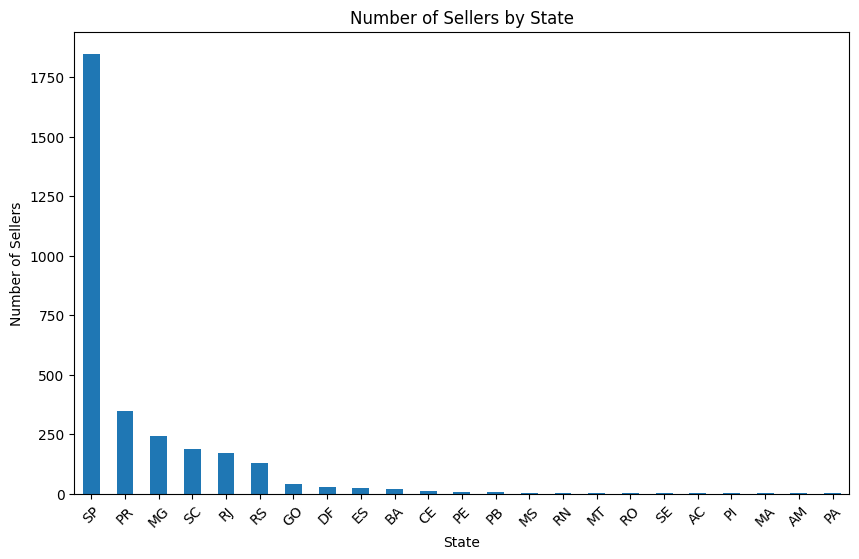

In [67]:
plt.figure(figsize=(10, 6))
seller_state_counts.plot(kind="bar")
plt.title("Number of Sellers by State")
plt.xlabel("State")
plt.ylabel("Number of Sellers")
plt.xticks(rotation=45)
plt.show()

### Observation

São Paulo has the highest number of sellers by a large margin, followed by Paraná and Minas Gerais.

In [68]:
seller_city_counts = sellers["seller_city"].value_counts().head(10)
seller_city_counts

seller_city
sao paulo         694
curitiba          127
rio de janeiro     96
belo horizonte     68
ribeirao preto     52
guarulhos          50
ibitinga           49
santo andre        45
campinas           41
maringa            40
Name: count, dtype: int64

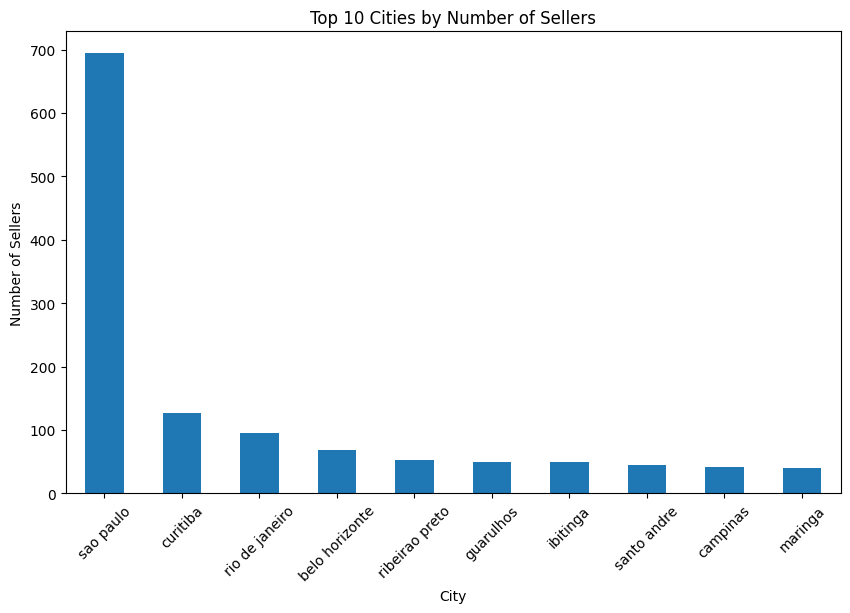

In [69]:
plt.figure(figsize=(10, 6))
seller_city_counts.plot(kind="bar")
plt.title("Top 10 Cities by Number of Sellers")
plt.xlabel("City")
plt.ylabel("Number of Sellers")
plt.xticks(rotation=45)
plt.show()

### Observation

São Paulo has the highest number of sellers among the top 10 cities, followed by Curitiba and Rio de Janeiro.

In [70]:
seller_activity = order_items["seller_id"].value_counts().head(10)
seller_activity

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: count, dtype: int64

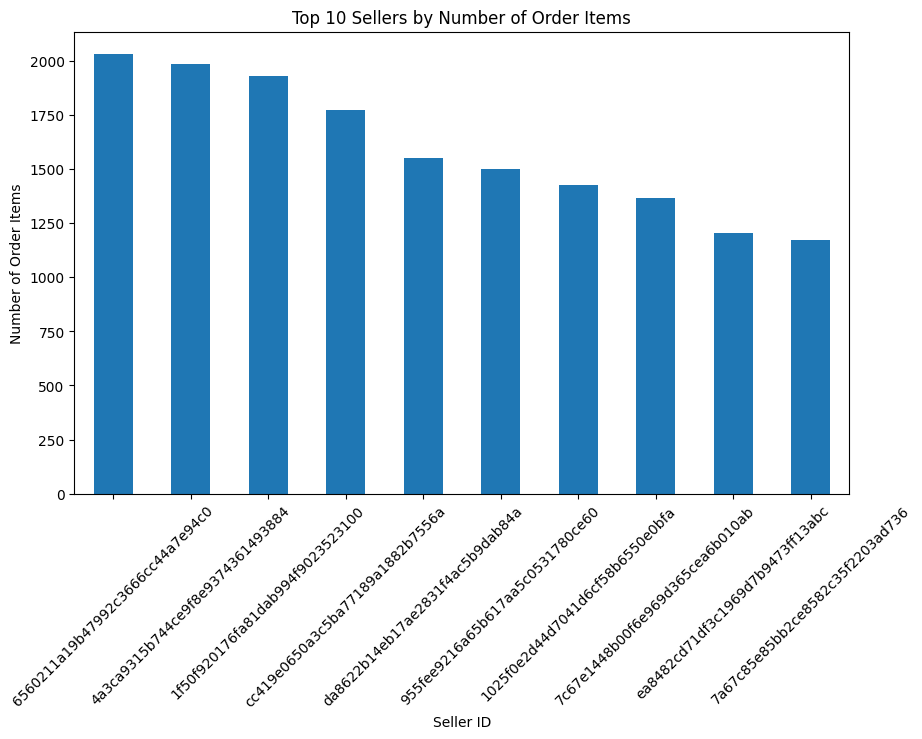

In [71]:
plt.figure(figsize=(10, 6))
seller_activity.plot(kind="bar")
plt.title("Top 10 Sellers by Number of Order Items")
plt.xlabel("Seller ID")
plt.ylabel("Number of Order Items")
plt.xticks(rotation=45)
plt.show()

### Observation

The top sellers handled a large number of order items, with the highest seller handling over 2,000 items.

# Geolocation EDA

Geolocation data is analyzed to understand the geographical distribution of locations.

### Analysis
- Locations by state
- Latitude distribution
- Longitude distribution

In [72]:
geolocation["geolocation_lat"].describe()

count    738307.000000
mean        -21.000104
std           5.883433
min         -34.622400
25%         -23.603071
50%         -22.873623
75%         -19.923396
max           4.482242
Name: geolocation_lat, dtype: float64

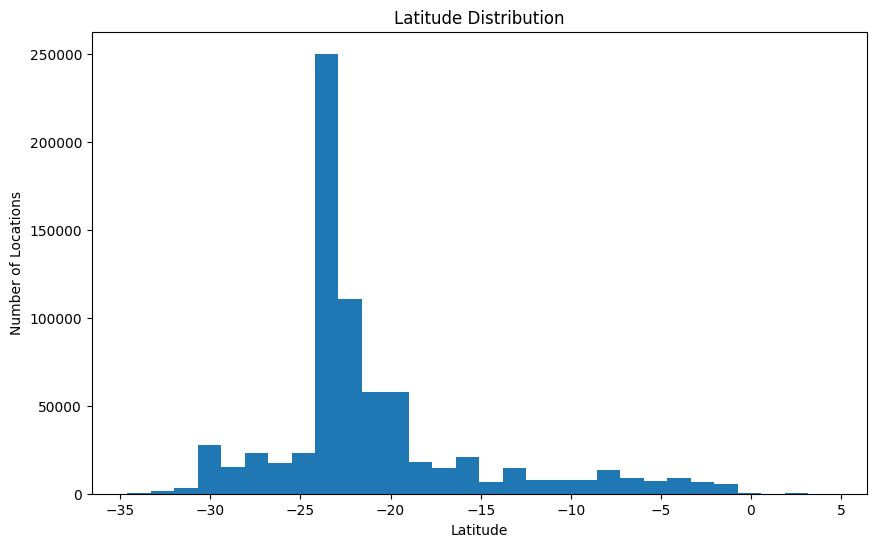

In [73]:
plt.figure(figsize=(10, 6))
geolocation["geolocation_lat"].plot(kind="hist", bins=30)
plt.title("Latitude Distribution")
plt.xlabel("Latitude")
plt.ylabel("Number of Locations")
plt.show()

### Observation

The latitude values are mostly concentrated between approximately -25 and -15, with a smaller number of locations outside this range.

In [74]:
geolocation["geolocation_lng"].describe()

count    738307.000000
mean        -46.461978
std           4.382980
min         -72.930746
25%         -48.867831
50%         -46.647299
75%         -43.837210
max         -32.402779
Name: geolocation_lng, dtype: float64

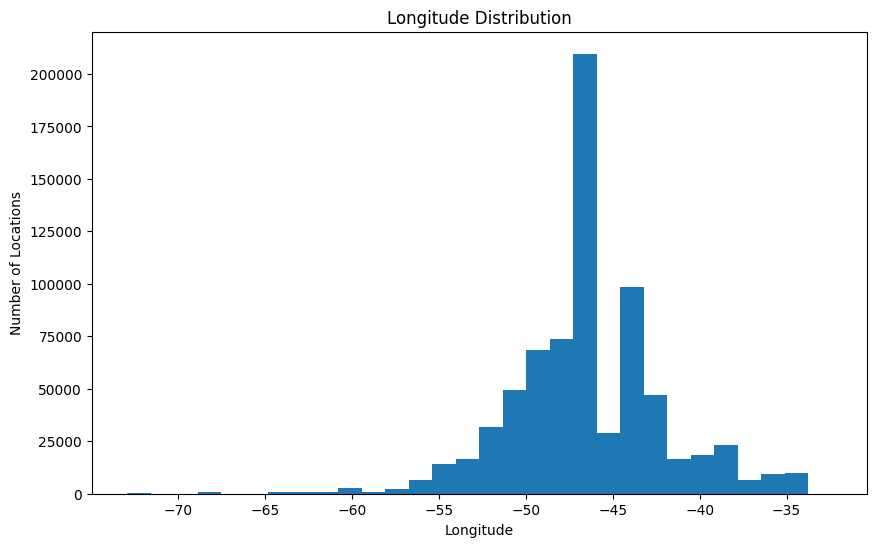

In [75]:
plt.figure(figsize=(10, 6))
geolocation["geolocation_lng"].plot(kind="hist", bins=30)
plt.title("Longitude Distribution")
plt.xlabel("Longitude")
plt.ylabel("Number of Locations")
plt.show()

### Observation

The longitude values are mainly concentrated around -50 to -40, with a smaller number of locations extending toward the lower and higher longitude ranges.

# Category Translation EDA

Category translation data is analyzed to understand the available product categories in Portuguese and English.

### Analysis
- Product category names
- Category translations

In [76]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [77]:
category_translation["product_category_name_english"].value_counts().head(10)

product_category_name_english
health_beauty            1
computers_accessories    1
auto                     1
bed_bath_table           1
furniture_decor          1
sports_leisure           1
perfumery                1
housewares               1
telephony                1
watches_gifts            1
Name: count, dtype: int64

In [78]:
category_translation["product_category_name_english"].nunique()

71

### Observation

The dataset contains 71 unique product categories, with each category having a corresponding English translation.

# **Combined EDA / Business Analysis**

# Sales Analysis

Sales data is analyzed to understand revenue trends, product sales, and purchasing patterns.

### Analysis
- Total sales
- Monthly sales trend
- Sales by product category

In [79]:
total_sales = order_items["price"].sum()
total_sales

np.float64(13591643.7)

### Observation

The total product sales value in the dataset is approximately ₹1.36 crore.

In [80]:
monthly_sales = (
    order_items.merge(
        orders[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="left"
    )
)

monthly_sales["order_purchase_timestamp"] = pd.to_datetime(
    monthly_sales["order_purchase_timestamp"]
)

monthly_sales = (
    monthly_sales.groupby(
        monthly_sales["order_purchase_timestamp"].dt.to_period("M")
    )["price"]
    .sum()
    .sort_index()
)

monthly_sales

order_purchase_timestamp
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64

### Observation

November 2017 recorded the highest monthly sales, at approximately ₹10.10 lakh. Sales generally increased over time with some month-to-month fluctuations.

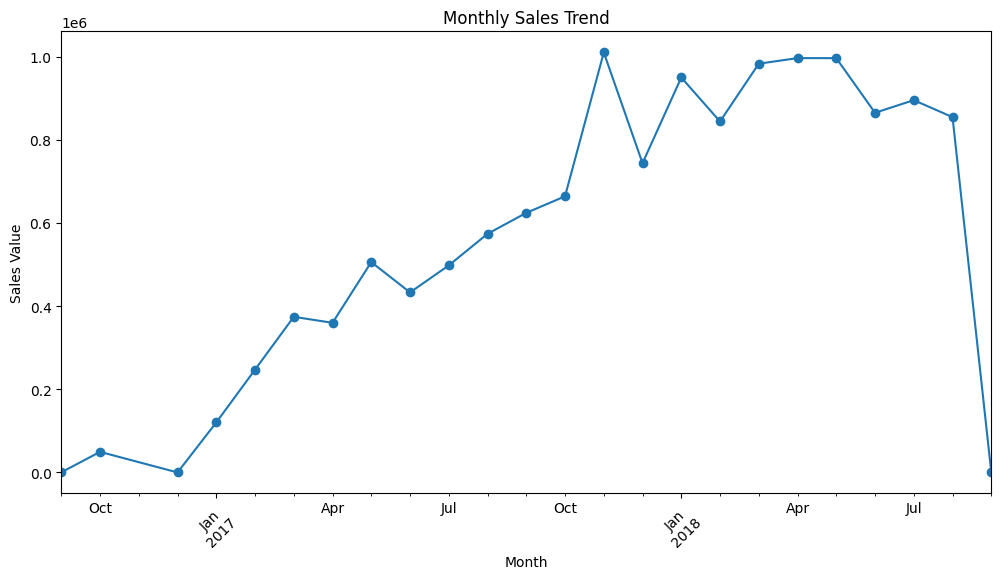

In [81]:
plt.figure(figsize=(12, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)

plt.show()

In [82]:
category_sales = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

category_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim


In [83]:
category_sales_value = (
    category_sales.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_sales_value.head(10)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

### Observation

Beleza, saude has the highest sales value, followed by relogios, presentes and cama, mesa, banho.

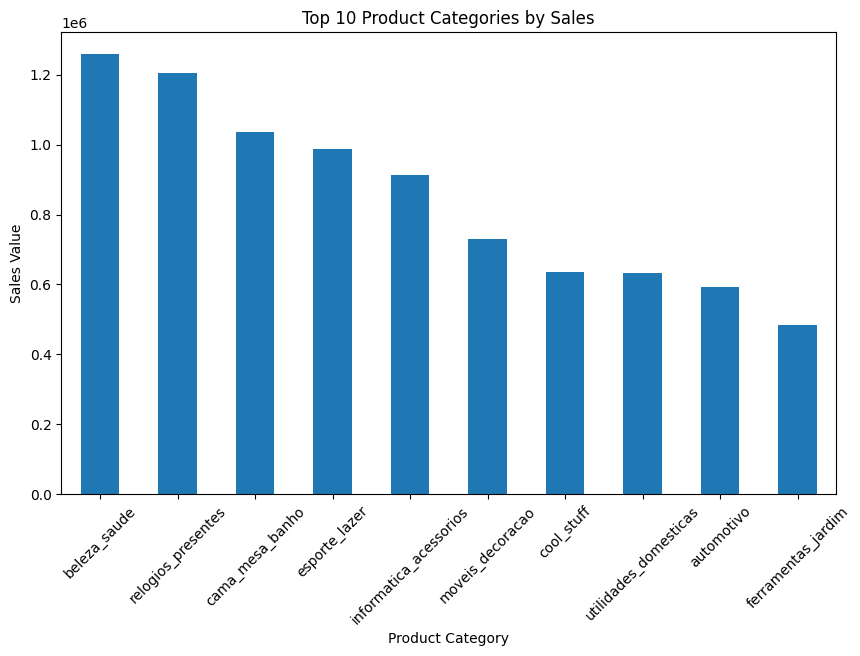

In [84]:
plt.figure(figsize=(10, 6))

category_sales_value.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Product Category")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)

plt.show()

In [85]:
seller_sales = (
    order_items.groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

seller_sales.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

### Observation

The top seller generated approximately ₹2.29 lakh in product sales, followed by sellers with approximately ₹2.23 lakh and ₹2.00 lakh in sales.

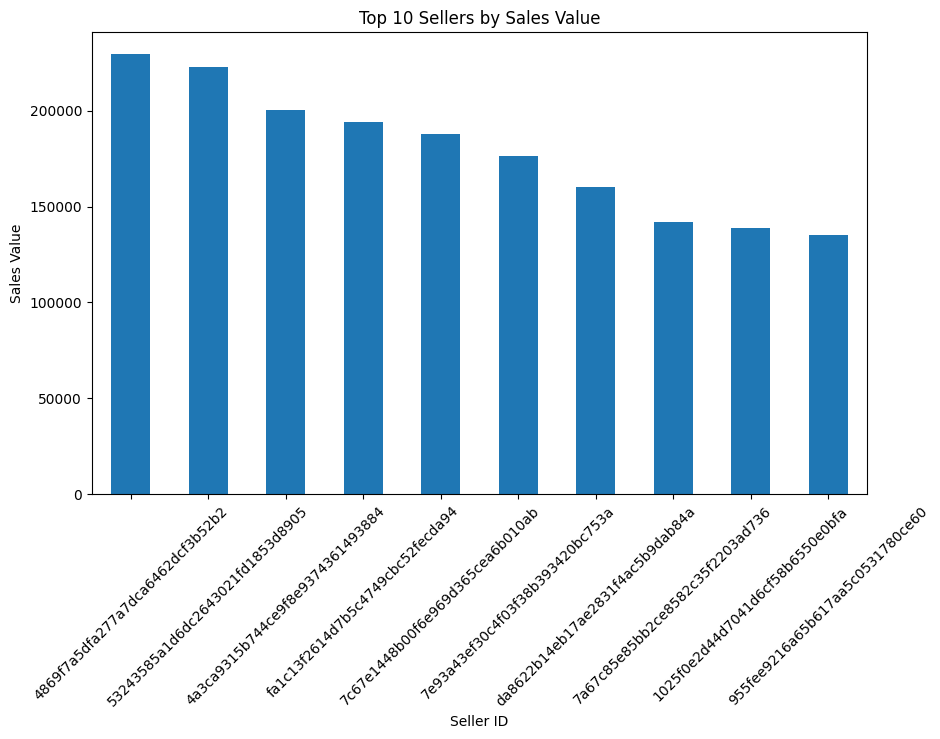

In [86]:
plt.figure(figsize=(10, 6))

seller_sales.head(10).plot(kind="bar")

plt.title("Top 10 Sellers by Sales Value")
plt.xlabel("Seller ID")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)

plt.show()

In [87]:
order_sales = order_items.groupby("order_id")["price"].sum()

average_order_value = order_sales.mean()

average_order_value

np.float64(137.75407637889444)

### Observation

The average product sales value per order is approximately ₹137.75.

In [88]:
payment_sales = payments.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)

payment_sales

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

### Observation

Credit card payments account for the highest payment value, followed by boleto. Voucher and debit card payments contribute much smaller amounts.

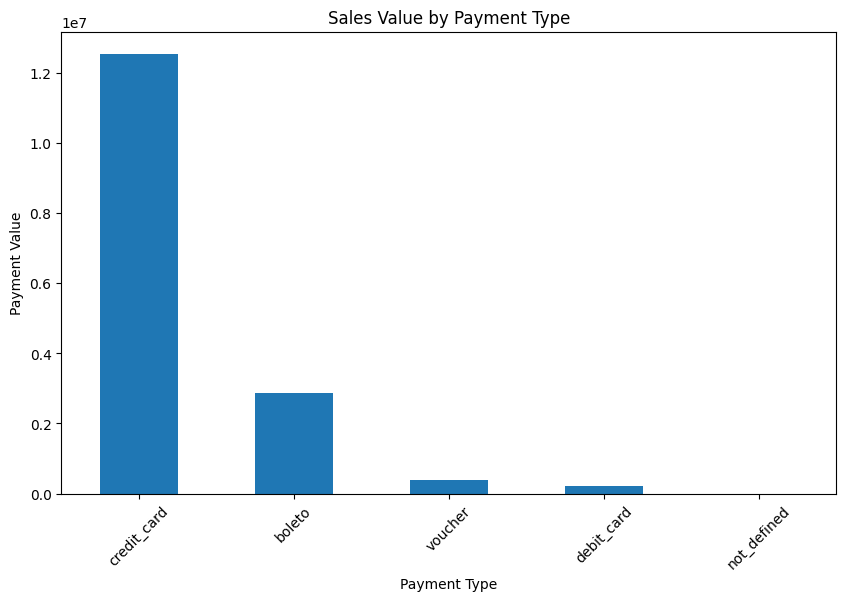

In [89]:
plt.figure(figsize=(10, 6))

payment_sales.plot(kind="bar")

plt.title("Sales Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Payment Value")
plt.xticks(rotation=45)

plt.show()

In [90]:
review_delivery = delivered_orders[
    ["order_id", "delivery_days"]
].merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="inner"
)

review_delivery.head()

,order_id,delivery_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,4
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,4
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,5
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,5


In [91]:
review_delivery["delivery_range"] = pd.cut(
    review_delivery["delivery_days"],
    bins=[0, 5, 10, 15, 30, float("inf")],
    labels=["1-5 days", "6-10 days", "11-15 days", "16-30 days", "30+ days"]
)

delivery_review_score = (
    review_delivery.groupby("delivery_range", observed=False)["review_score"]
    .mean()
)

delivery_review_score

delivery_range
1-5 days      4.430943
6-10 days     4.347884
11-15 days    4.245394
16-30 days    3.866279
30+ days      2.175639
Name: review_score, dtype: float64

### Observation

Orders delivered within 1–5 days have the highest average review score, while orders taking more than 30 days have the lowest average review score.

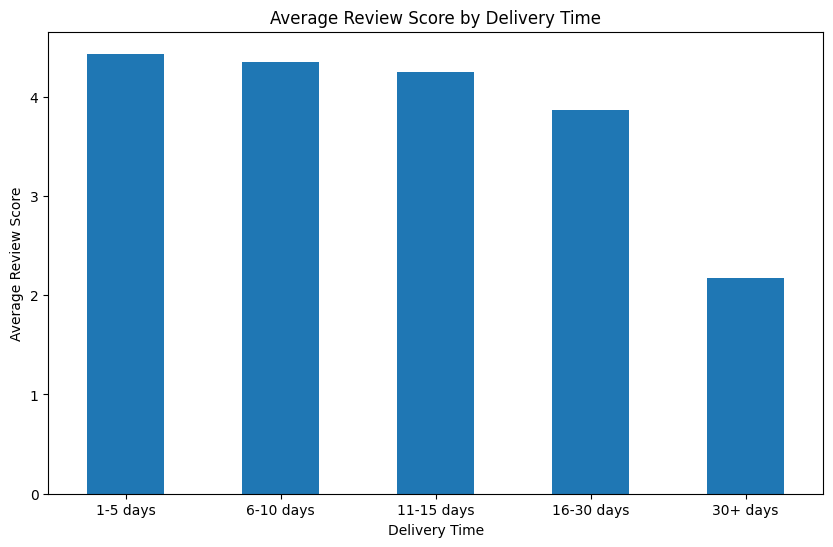

In [92]:
plt.figure(figsize=(10, 6))

delivery_review_score.plot(kind="bar")

plt.title("Average Review Score by Delivery Time")
plt.xlabel("Delivery Time")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)

plt.show()

**Order → Customer → Customer State → Price**

In [93]:
state_sales = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
)

state_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,SP


In [94]:
state_sales_value = (
    state_sales
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

state_sales_value

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
PE     262788.03
CE     227254.71
PA     178947.81
MT     156453.53
MA     119648.22
MS     116812.64
PB     115268.08
PI      86914.08
RN      83034.98
AL      80314.81
SE      58920.85
TO      49621.74
RO      46140.64
AM      22356.84
AC      15982.95
AP      13474.30
RR       7829.43
Name: price, dtype: float64

### Observation

São Paulo (SP) recorded the highest product sales value at approximately R$5.20 million, followed by Rio de Janeiro (RJ) at R$1.82 million and Minas Gerais (MG) at R$1.59 million.

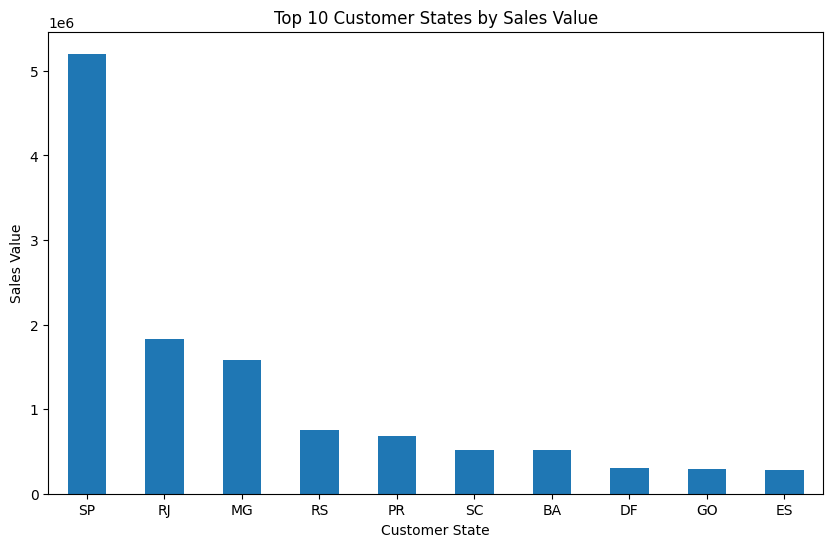

In [95]:
plt.figure(figsize=(10, 6))

state_sales_value.head(10).plot(kind="bar")

plt.title("Top 10 Customer States by Sales Value")
plt.xlabel("Customer State")
plt.ylabel("Sales Value")
plt.xticks(rotation=0)

plt.show()

In [96]:
category_item_count = (
    order_items
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
)

category_item_count.head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
dtype: int64

In [97]:
category_item_count = (
    category_sales
    .groupby("product_category_name")
    .size()
    .sort_values(ascending=False)
)

category_item_count.head(10)

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
dtype: int64

### Observation

Cama, mesa, banho had the highest number of items sold, followed by beleza, saude and esporte, lazer.

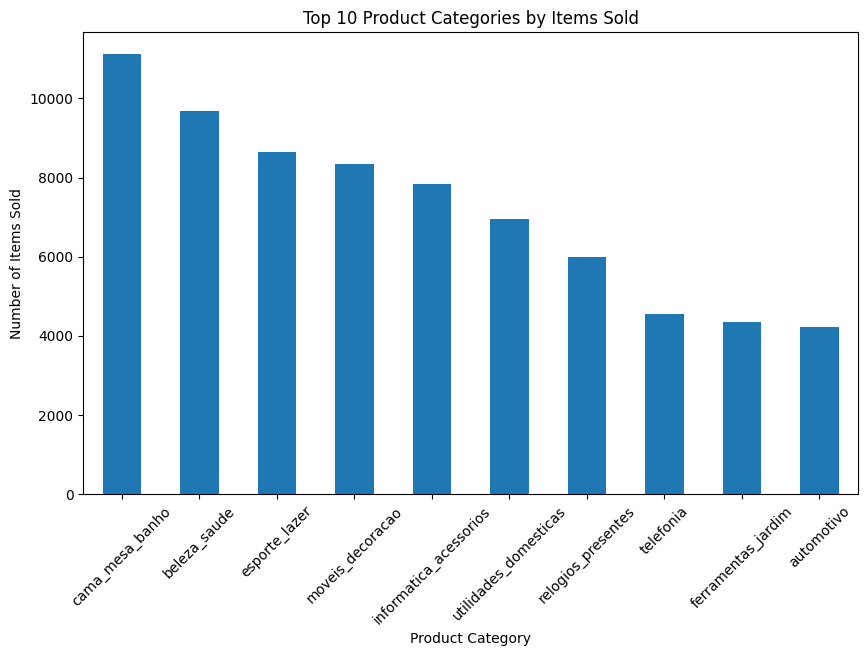

In [98]:
plt.figure(figsize=(10, 6))

category_item_count.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Product Category")
plt.ylabel("Number of Items Sold")
plt.xticks(rotation=45)

plt.show()

In [99]:
order_status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

order_status_percentage

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

### Observation

Most orders were successfully delivered, accounting for 97.02% of all orders. Shipped, canceled and unavailable orders represented much smaller proportions.

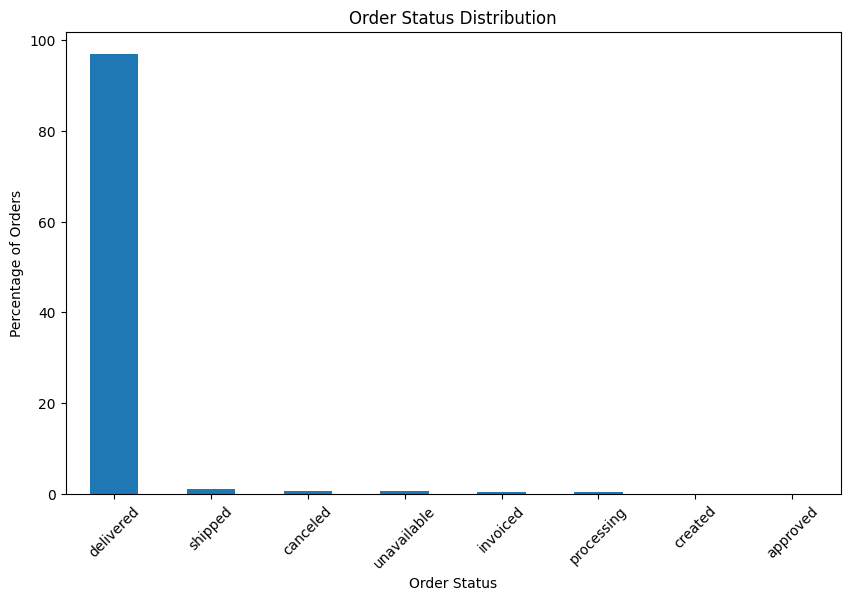

In [100]:
plt.figure(figsize=(10, 6))

order_status_percentage.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=45)

plt.show()

In [101]:
order_items["price_range"] = pd.cut(
    order_items["price"],
    bins=[0, 50, 100, 500, 1000, float("inf")],
    labels=["0-50", "51-100", "101-500", "501-1000", "1000+"]
)

freight_by_price = (
    order_items
    .groupby("price_range", observed=False)["freight_value"]
    .mean()
)

freight_by_price

price_range
0-50        14.765093
51-100      17.879832
101-500     25.018272
501-1000    43.056522
1000+       60.148578
Name: freight_value, dtype: float64

### Observation

Average freight value increases as product price increases. Products priced above R$1,000 have the highest average freight value at approximately R$60.15, while products priced at R$0–50 have the lowest at approximately R$14.77.

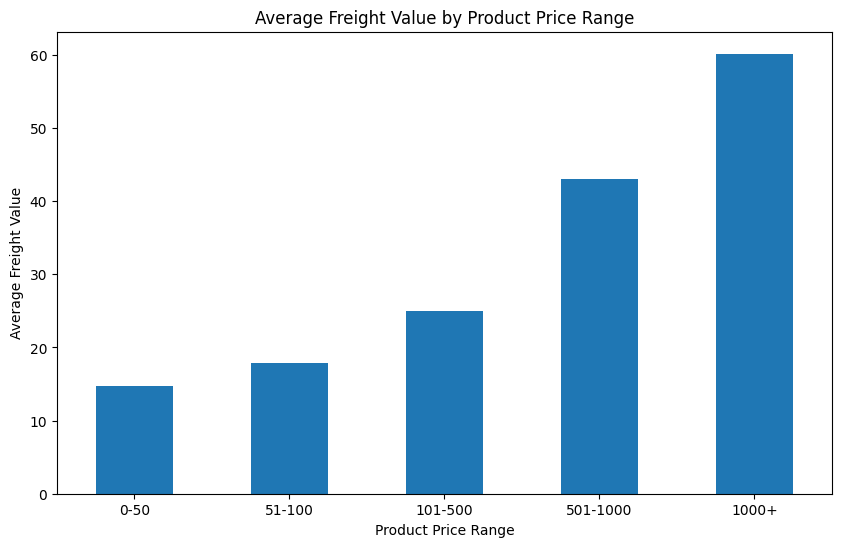

In [102]:
plt.figure(figsize=(10, 6))

freight_by_price.plot(kind="bar")

plt.title("Average Freight Value by Product Price Range")
plt.xlabel("Product Price Range")
plt.ylabel("Average Freight Value")
plt.xticks(rotation=0)

plt.show()

# Key Business Insights

The analysis highlights important patterns in sales, customers, payments, delivery, and product performance.

### Key Insights

- Total product sales were approximately R$13.59 million.
- November 2017 recorded the highest monthly sales at approximately R$1.01 million.
- Beleza, saude generated the highest sales value among product categories.
- São Paulo recorded the highest sales value among customer states.
- Credit card payments contributed the highest payment value.
- 97.02% of orders were delivered.
- Longer delivery times were associated with lower average review scores.
- Higher-priced products had higher average freight values.

# Project Conclusion

This analysis provides an overview of customer behavior, sales performance, product categories, payment methods, delivery performance, and customer satisfaction using the Brazilian E-Commerce dataset.

The analysis helps identify major sales categories, important customer regions, common payment methods, delivery patterns, and factors related to customer reviews.

In [103]:
import pandas as pd

orders_csv = pd.read_csv("../cleaned_datasets/cleaned_orders.csv")

orders_csv.shape

(99441, 8)

In [104]:
orders_csv["order_id"].nunique()

99441